**Author:** Gustavo Galvao

# Analysis of Educational Attainment as a Predictor for County-Level GDP

## Project Overview
This notebook investigates the relationship between human capital (measured by Bachelor's Degree attainment) and economic output (Real GDP) across Georgia's counties. The goal is to build a predictive model capable of estimating GDP trajectories based on educational shifts.

### The "Data Desert" Challenge (2003-2009)
A primary challenge of this study is the lack of annual education data prior to 2010. While county GDP data is available for the full 2003-2023 window, education data is anchored by the 2000 Decennial Census and the 2010 ACS estimates.

### Research Objectives
* **Baseline Validation:** Use the "Gold Standard" data (2010-2023) to establish a baseline correlation between Education and Total GDP.
* **Methodological Testing:** Compare three imputation methods (Linear Interpolation, Back-filling, and Baseline/Drop) to fill the 2003-2009 education gap.

### Modeling Strategy: Total GDP First
Due to heavy data suppression (NaNs) in industry-specific GDP columns many counties, this analysis prioritizes **Total Real GDP Growth** to maintain a consistent signal across all 159 counties.

## Notebook Structure
This notebook follows a modular workflow separated into 4 main chapters:

1.  **Data Ingestion & Cleaning:** Load TerraTrends dataset and filter for relevant predictors and years.
2. **Exploratory Data Analysis (EDA):**
    * Lagged Correlation Analysis ($t$ through $t-5$) to find the economic "reaction time."
    * Analyzing if change in education correlates better with GDP increase in opposition to pure higher education attainment percentage
3. **Imputation Experiment & Model Benchmarking:** Comparing Mean Absolute Error (MAE) and $R^2$ across datasets and models to evaluate feature viability:
    * **Dataset A:** Linear Interpolation (Steady growth assumption).
    * **Dataset B:** Back-filling (Stationary assumption).
    * **Dataset C:** Baseline (Excluding education metrics entirely).

## Tech Stack
* **Language:** Python 3.10+.
* **Libraries:** `pandas`, `scikit-learn`, `seaborn`.
* **Data Sources:** IPUMS NHGIS (Census/ACS), Bureau of Economic Analysis (BEA).


# Data Ingestion and Cleaning

## Data Source and Loading

The notebook first begins by loading the TerraTrends updated data set (which now includes all population estimates from all counties from 2003 to 2023) which can be found in the [GitHub repository containing this notebook](https://github.com/Gustavo-Galvao-e-Silva/TerraTrends). This data set contains many columns, but we will focus on one single feature and a simplified predictor:
* **Bachelor_Degree_or_Higher_Pct (predictor):** measures the percentage of adults aged 25+ who have at least a Bachelor's degree
* **Percent_Change_Real_GDP (target):** measures the real GDP year-over-year

## Data Selection, Cleaning, and Temporal Filtering

To ensure a high "signal-to-noise" ratio during the initial Exploratory Data Analysis (EDA), we prioritize the **"Gold Standard"** period (2010-2023). This window provides the most reliable annual education data, allowing us to establish a baseline correlation before attempting to impute values for the 2003-2009 "data desert." Lastly, as the data is normally distributed, we can remove some outliers to achieve more conclusive results.

## Preliminary Data Check

Before moving to the analysis, we perform a "health check" on the dataframe to identify missing values and confirm data types, and as seen, the output from df.describe() shows the correct number of rows and no null entries.

In [9]:
# Chapter 1: Data Ingestion & Cleaning
import os

import matplotlib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Configuration constants
INPUT_DATA_PATH = "../data/input"
INPUT_FILE_NAME = "merged_data.csv"
TARGET_YEARS = list(range(2010, 2024))
PREDICTOR_COLUMN = "Bachelor_Degree_or_Higher_Pct"
TARGET_COLUMN = "Percent_Change_Real_GDP"
POPULATION_COLUMN = "TOT_POP"
ID_COLUMNS = ["County", "Year"]
RELEVANT_COLUMNS = ID_COLUMNS + [TARGET_COLUMN] + [PREDICTOR_COLUMN] + [POPULATION_COLUMN]
MAX_LAG = 5

# Loading and filtering
georgia_county_dataset_path = os.path.join(INPUT_DATA_PATH, INPUT_FILE_NAME)
georgia_county_df = pd.read_csv(georgia_county_dataset_path)
education_gdp_df = georgia_county_df[georgia_county_df["Year"].isin(TARGET_YEARS)][RELEVANT_COLUMNS].sort_values(by=ID_COLUMNS)

# Display and health checks
# education_gdp_df.describe(include="all")

# Exploratory Data Analysis (EDA)

## Lagged Correlation Analysis

Now, we begin working on analyzing how strongly education correlates with year-over-year GDP growth across different time horizons.

In regional economics, the impact of human capital is rarely instantaneous. There is typically a "gestation period" between an individual obtaining a degree and that education manifesting as increased local productivity or innovation. To account for this, we conduct a Lagged Correlation Analysis, shifting our education data forward by 0 to 5 years (t through t?5).

### Objectives of this Analysis

* Identify the "Reaction Time": Determine the specific number of years it takes for shifts in educational attainment to show the strongest statistical link to GDP changes.
* Establish Signal Strength: Quantify the linear relationship (Pearson Correlation) to assess if education is a "leading indicator" or merely a coincidental one.

In [10]:
def create_lagged_education_df(df: pd.DataFrame, max_lag: int, county_column_name: str, education_column_name: str) -> pd.DataFrame:
    new_df = df.copy()
    for i in range(max_lag + 1):
        new_column_name = f"education_t-{i}" if i > 0 else f"education_t"
        new_df[new_column_name] = new_df.groupby(county_column_name)[education_column_name].shift(i)

    return new_df

def remove_outliers_iqr(df: pd.DataFrame, column: str, multiplier: float = 1.5) -> pd.Series:
    q_1 = df[column].quantile(0.25)
    q_3 = df[column].quantile(0.75)
    iqr = q_3 - q_1
    lower_bound = q_1 - multiplier * iqr
    upper_bound = q_3 + multiplier * iqr
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

def display_lagged_scatter_plots(df: pd.DataFrame, max_lag: int, gdp_column_name: str) -> None:
    n_plots = max_lag + 1
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(15, 5 * n_rows),
        sharex=False,
        sharey=True,
        dpi=150
    )

    axes_flat = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

    for i in range(n_plots):
        education_column_name = f"education_t-{i}" if i > 0 else "education_t"
        valid_df = df.dropna(subset=[education_column_name, gdp_column_name])

        sns.regplot(
            ax=axes_flat[i],
            data=valid_df,
            x=education_column_name,
            y=gdp_column_name,
            line_kws={"color": "red"},
            scatter_kws={"color": "blue"}
        )

        axes_flat[i].set_title(f"{i} Year Lagged Education Level-GDP Scatter Plot")
        axes_flat[i].set_xlabel(f"Bachelor's attainment percentage ({i} year lag)")
        axes_flat[i].set_ylabel("GDP change")

    for j in range(n_plots, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    plt.show()

def calculate_education_gdp_correlation(df: pd.DataFrame, max_lag: int, gdp_column_name: str) -> list[tuple[float]]:
    correlations = []
    for i in range(max_lag + 1):
        education_column_name = f"education_t-{i}" if i > 0 else f"education_t"
        valid_df = df.dropna(subset=education_column_name)
        corr, p = pearsonr(valid_df[gdp_column_name], valid_df[education_column_name])
        correlations.append((p, corr))

    return correlations

def display_education_lags_correlation(correlations: list[tuple[float]], max_lag: int) -> None:
    lags = list(range(max_lag + 1))
    p_values = [corr[0] for corr in correlations]
    corr_values = [corr[1] for corr in correlations]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(lags, corr_values, marker='o', linestyle='--', color='teal')
    ax1.set_title("Pearson Correlation Strength by Lag Year")
    ax1.set_xlabel("Years Lagged")
    ax1.set_ylabel("Correlation Coefficient")
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

    ax2.plot(lags, p_values, marker='s', linestyle='--', color='coral')
    ax2.set_title("P-values by Lag Year")
    ax2.set_xlabel("Years Lagged")
    ax2.set_ylabel("P-value")
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.05, color='red', linestyle=':', linewidth=1, label='Significance Level (? = 0.05)')
    ax2.legend()

    plt.tight_layout()
    plt.show()

### Lagged Education vs. GDP Change Scatter Plots

#### Plotting Methods and Goals:

Following the removal of extreme GDP volatility outliers via the IQR method, we evaluate the predictive strength of human capital across six temporal horizons. The scatter plots below visualize the annual Real GDP Percent Change in relation to the Bachelor's Degree Attainment Rate, lagged from 0 to 5 years.

The grid is organized chronologically (increasing from t to t?5) from left to right and top to bottom. This configuration allows us to observe:

* Variance Sensitivity: Whether a specific time lag results in a "tighter" clustering of data points, indicating a more stable relationship.
* Trend-line Elasticity: Whether the slope of the regression line steepens at specific lags, revealing the "gestation period" or response-time required for educational shifts to manifest as measurable economic growth.

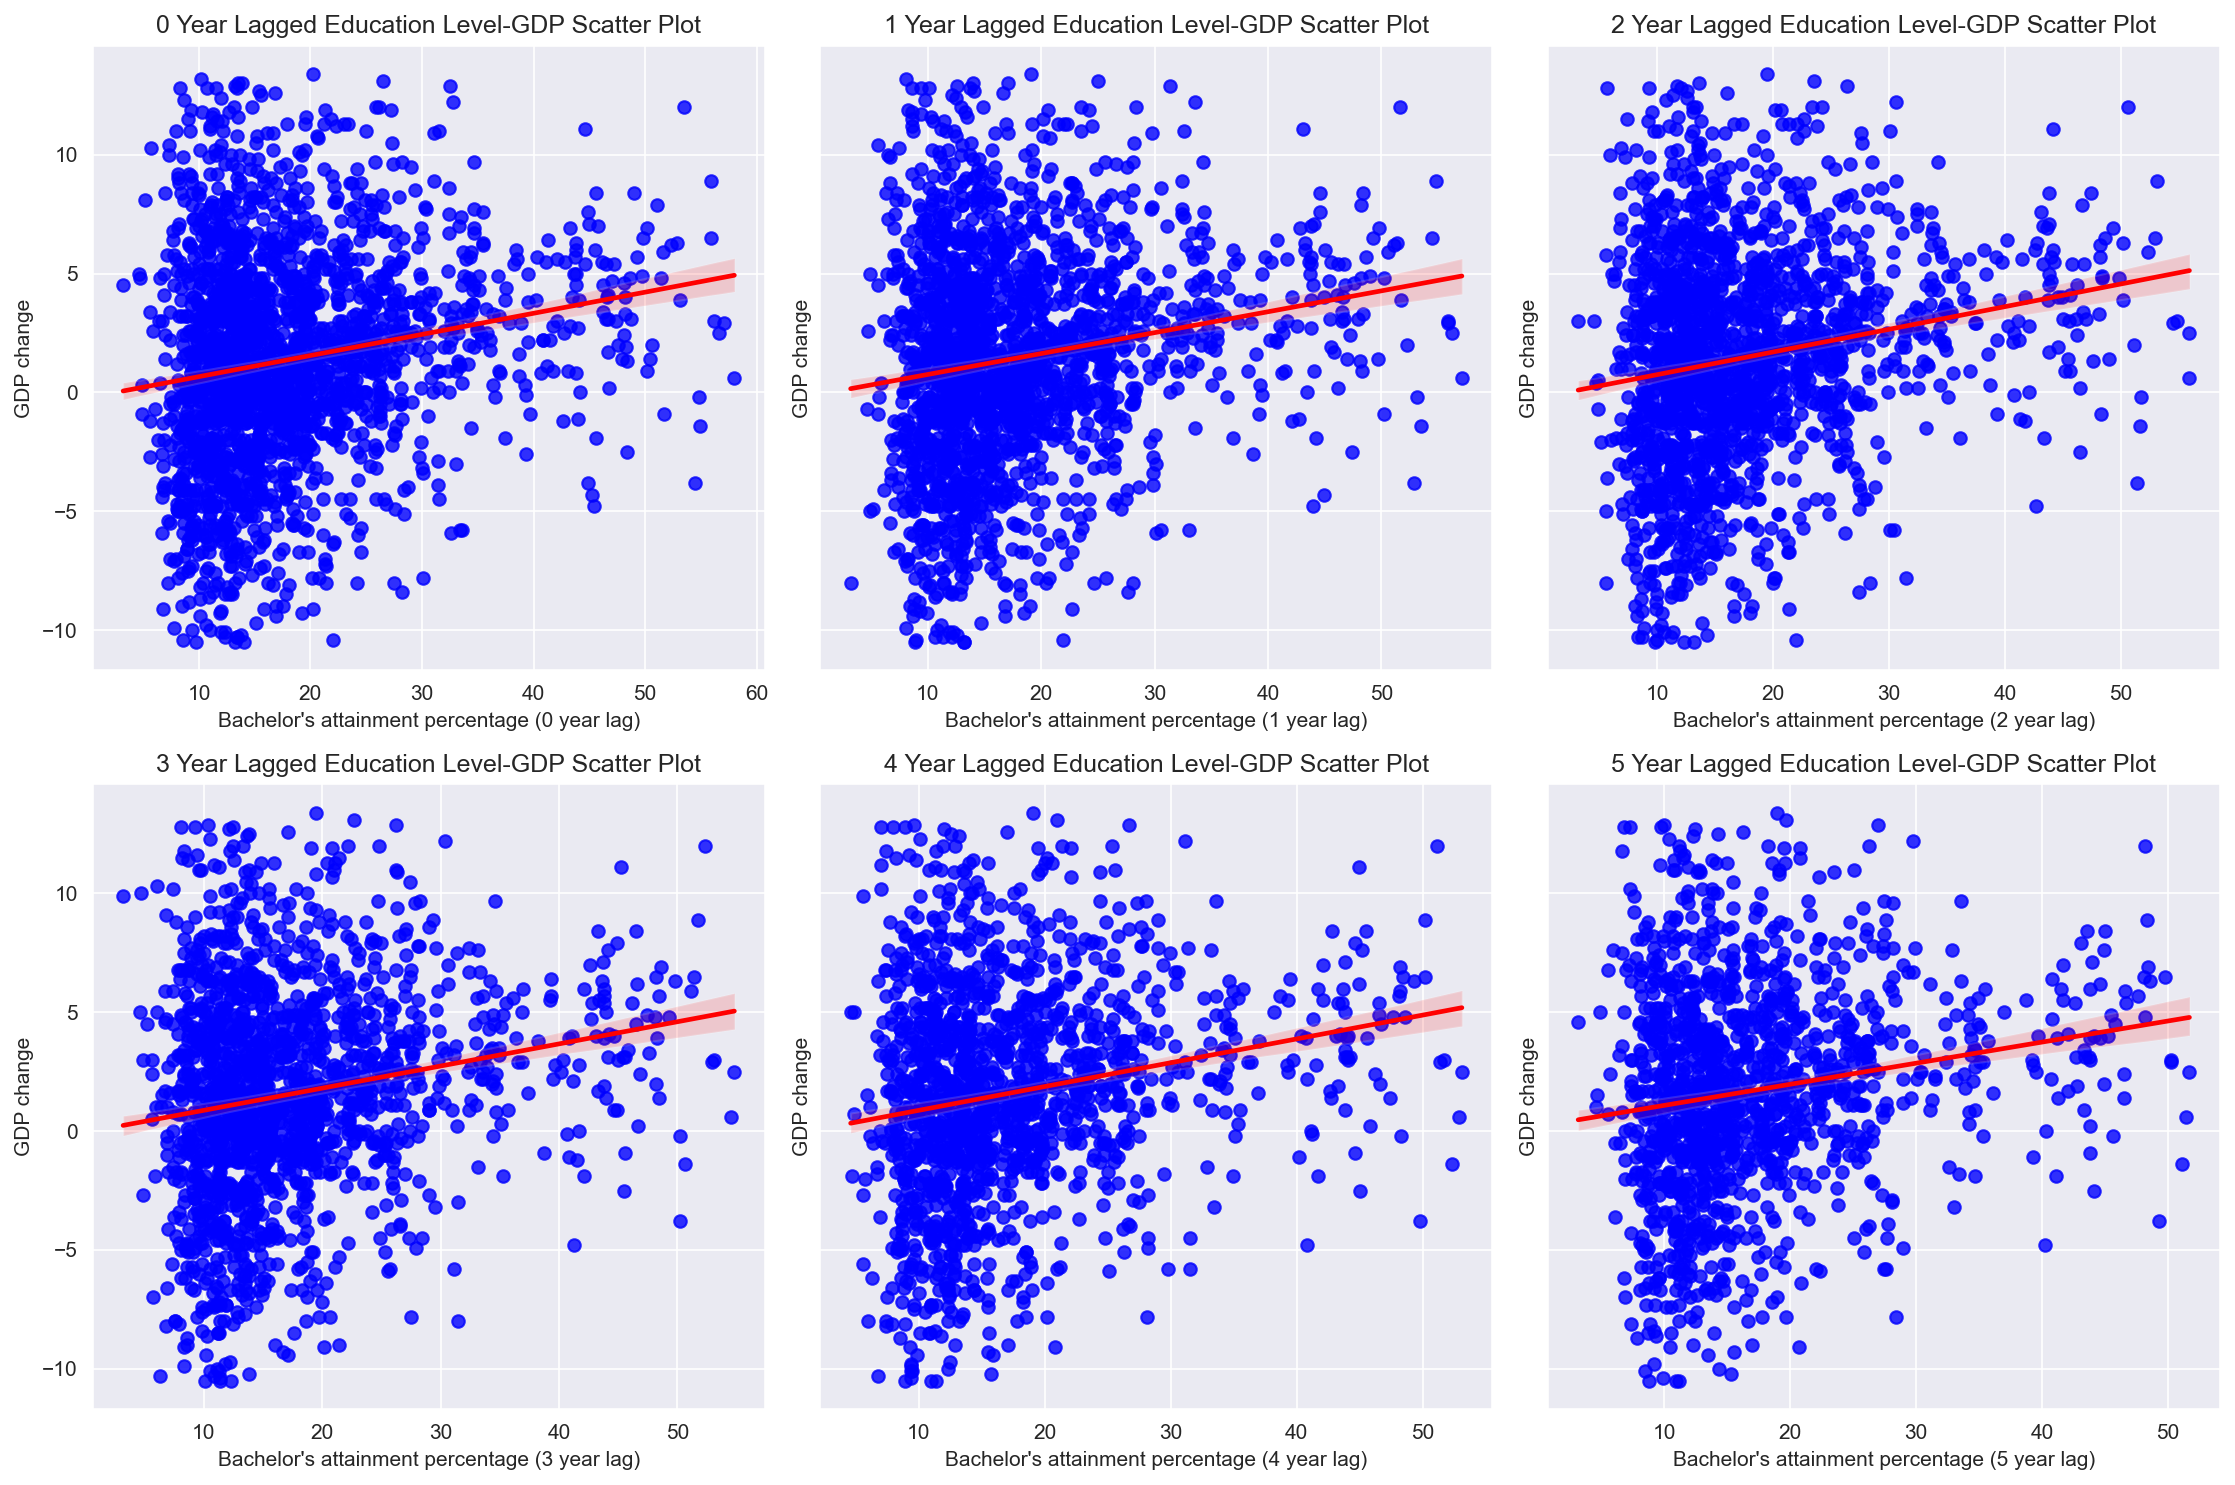

In [11]:
# Generate lagged education features
lagged_df = create_lagged_education_df(education_gdp_df, MAX_LAG, "County", PREDICTOR_COLUMN)
cleaned_lagged_df = remove_outliers_iqr(lagged_df, TARGET_COLUMN, 1.5)

# Display lagged education scatter plots
display_lagged_scatter_plots(cleaned_lagged_df, MAX_LAG, TARGET_COLUMN)


#### The Results:

The scatter plots provide an initial look into the predictive power of educational attainment on annual GDP growth. Several key observations emerge:

* Statistical Dispersion: The "cloud" of data points is highly dispersed across all 159 counties. This high variance suggests that while a relationship exists, it is subject to significant "noise" from other variables.
* Weak Linear Signal: The regression lines across all six plots maintain a consistently shallow, positive slope. With correlation coefficients (r) stagnating around 0.18, education level appears to be a "weak" linear predictor of annual growth.
* Temporal Invariance: Interestingly, increasing the lag from 0 to 5 years does not significantly "tighten" the scatter spread or dramatically improve the correlation. This suggests that the relationship between human capital and growth is structural (a permanent foundation) rather than dynamic (a specific trigger that sets off growth after X years). This result is very strongly supported by the next graph, which displays how the correlation between the two aforementioned parameters changes with increased lag.

#### Modelling Significance:

These results indicate that **a simple Linear Regression model will likely underperform. However, the consistent positive slope confirms that a signal does exist**. The next phase of this project will utilize non-linear algorithms (Random Forest and a simple Neural Network) to determine if these models can extract complex, high-dimensional patterns that simple linear correlations fail to capture.

### Correlation vs. Differing Lag Levels Graph

While the scatter plots provided a visual sense of the data's dispersion, the line graph below offers a precise mathematical summary of the relationship. By plotting the Pearson Correlation Coefficient (r) against each lag year (0-5), we can definitively see if a "peak" exists.

#### Goals of this Visualization:

* **Identify the Apex:** Pinpoint exactly which lag year provides the strongest signal for our model. In our findings, the "Level" of education shows a distinct, albeit modest, peak compared to the delta.
* **Assess Sensitivity:** Determine if the correlation is stable over time or if it decays rapidly as the lag increases. The high stability of the p-values for education levels (ranging from 10^-10 to 10^-17) suggests a very permanent structural relationship between the existing stock of human capital and growth.
* **Benchmark for Modeling:** This graph establishes the "limit" of linear predictability. Any performance gain achieved by our eventual Machine Learning models over these r values will represent the "Non-Linear Lift" provided by more complex algorithms.

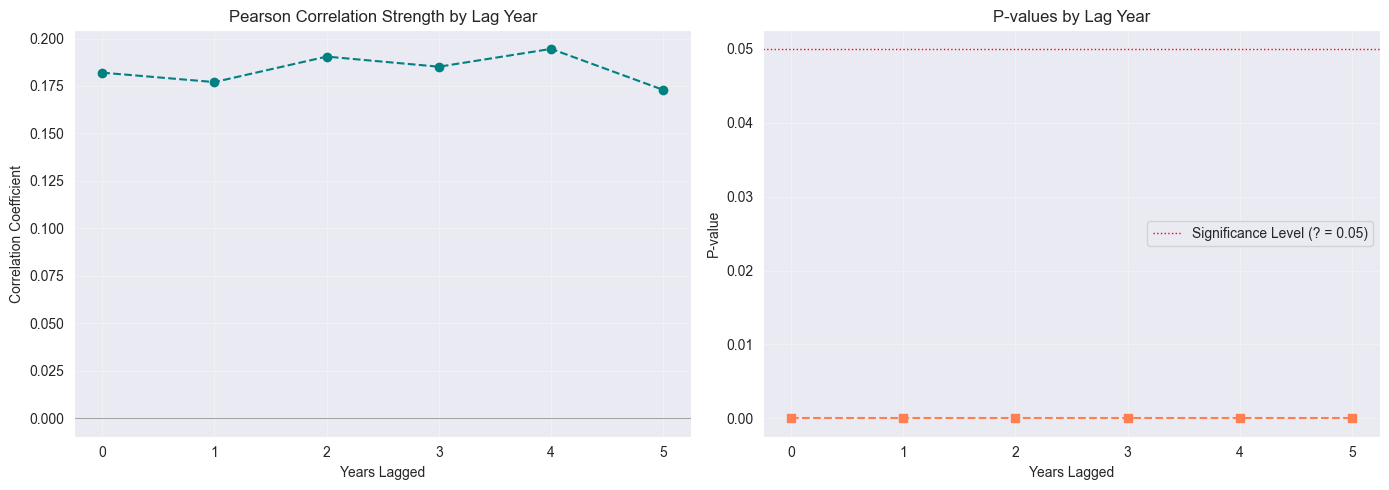

In [12]:
pearson_corrs = calculate_education_gdp_correlation(cleaned_lagged_df, MAX_LAG, TARGET_COLUMN)
display_education_lags_correlation(pearson_corrs, MAX_LAG)

#### The Results:

While the scatter plots showed significant dispersion, this line graph synthesizes those results to reveal the temporal behavior of our delta-on-delta predictor. Based on our analysis, we have the following insights:

* **Absence of a Temporal Peak:** Unlike the education levels, the Pearson correlation for education deltas shows no clear upward trend or "apex." The values fluctuate marginally between r = 0.009 and r = 0.021, eventually dipping to -0.026 at the 5-year lag. This suggests that annual changes in educational attainment do not have a cumulative linear "build-up" effect on GDP growth within this timeframe.
* **Persistent Statistical Insignificance:** The p-values for the delta-on-delta analysis are consistently high, ranging from 0.36 to 0.66. At no point does the lag reduce the p-value enough to approach the 0.05 significance threshold. This confirms that the year-over-year "flow" of new degrees is currently indistinguishable from statistical noise in predicting annual economic expansion.
* **Negligible Signal Strength:** With all r-values remaining below 0.03, the linear relationship is practically non-existent. This starkly contrasts with the "Level" analysis ($p < 10^{-16}$), reinforcing the conclusion that the total stock of human capital is an economically relevant predictor, while the annual rate of change is not.

#### Strategic Conclusion for Modeling:

The total lack of a significant signal in the Delta-on-Delta analysis indicates that raw annual changes in education should not be used as primary linear features. Instead, our modeling strategy will shift toward using **cumulative levels** or **smoothed rolling averages** to capture the impact of human capital. Since the delta fails to provide a leading indicator in a linear context, we will rely on Machine Learning models (such as Random Forest) to investigate if these deltas interact non-linearly with other variables--such as population density or industry specialization--to influence GDP.

## Education and GDP Delta-on-Delta Analysis

To further explore the possible relationship between education attainment and county GDP growth, we will now do a similar analysis, but instead **correlating GDP growth with education growth** (delta-on-delta). Many variables, especially complex economic ones, relate better to each other when their relative changes are analyzed instead of their level; thus, it is important we analyze if these two variables hold this form of correlation, and in what delta timespan is it strongest.

### Objectives of this Analysis

* **Establish Signal Strength:** Quantify the linear relationship (Pearson Correlation) to assess if education delta is a "leading indicator" or merely a coincidental one. Our current results (r ~= 0.01) suggest a very weak linear signal for short-term changes.
* **Assess Statistical Significance:** Determine if the changes are meaningful. With p-values as high as 0.665, we currently cannot reject the null hypothesis that there is no linear relationship between annual education deltas and GDP growth.
* **Examine Temporal Lags:** Identify if the "flow" of new degrees requires several years to manifest in the "delta" of GDP. Our results indicate that even with lagging, the year-over-year change remains an inconsistent predictor.

In [13]:
def create_lagged_delta_df(df: pd.DataFrame, max_lag: int, county_column_name: str, education_column_name: str) -> pd.DataFrame:
    new_df = df.copy()
    new_df['base_delta'] = new_df.groupby(county_column_name)[education_column_name].diff()

    for i in range(max_lag + 1):
        new_column_name = f"edu_delta_t-{i}"
        new_df[new_column_name] = new_df.groupby(county_column_name)['base_delta'].shift(i)

    return new_df

def display_lagged_delta_scatter_plots(df: pd.DataFrame, max_lag: int, gdp_column_name: str) -> None:
    n_plots = max_lag + 1
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(15, 5 * n_rows),
        sharex=False,
        sharey=False,
        dpi=150
    )

    axes_flat = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

    for i in range(n_plots):
        delta_column_name = f"edu_delta_t-{i}"
        valid_df = df.dropna(subset=[delta_column_name, gdp_column_name])

        if not valid_df.empty:
            sns.regplot(
                ax=axes_flat[i],
                data=valid_df,
                x=delta_column_name,
                y=gdp_column_name,
                line_kws={"color": "red"},
                scatter_kws={"color": "blue", "alpha": 0.5}
            )

            axes_flat[i].set_title(f"{i} Year Lagged Delta Education vs GDP")
            axes_flat[i].set_xlabel(f"Delta Bachelor's % ({i} year lag)")
            axes_flat[i].set_ylabel("GDP Variable")

    for j in range(n_plots, len(axes_flat)):
        axes_flat[j].set_visible(False)

    plt.tight_layout()
    plt.show()

def calculate_delta_gdp_correlation(df: pd.DataFrame, max_lag: int, gdp_column_name: str) -> list[tuple[float, float]]:
    correlations = []
    for i in range(max_lag + 1):
        delta_column_name = f"edu_delta_t-{i}"
        valid_df = df[[delta_column_name, gdp_column_name]].dropna()

        if len(valid_df) > 1:
            corr, p = pearsonr(valid_df[gdp_column_name], valid_df[delta_column_name])
            correlations.append((p, corr))
        else:
            correlations.append((np.nan, np.nan))

    return correlations

def display_delta_lags_correlation(correlations: list[tuple[float, float]], max_lag: int) -> None:
    lags = list(range(max_lag + 1))
    p_values = [corr[0] for corr in correlations]
    corr_values = [corr[1] for corr in correlations]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    ax1.plot(lags, corr_values, marker='o', linestyle='--', color='teal')
    ax1.set_title("Pearson Correlation Strength (Delta Education vs GDP)")
    ax1.set_xlabel("Years Lagged")
    ax1.set_ylabel("Correlation Coefficient (r)")
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

    ax2.plot(lags, p_values, marker='s', linestyle='--', color='coral')
    ax2.set_title("P-values by Lag Year")
    ax2.set_xlabel("Years Lagged")
    ax2.set_ylabel("P-value")
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.05, color='red', linestyle=':', linewidth=1.5, label='Significance Level (? = 0.05)')
    ax2.legend()

    plt.tight_layout()
    plt.show()

### Education Change vs. GDP Change Scatter Plots

#### Plotting Methods and Goals:

We again remove extreme GDP volatility outliers via the IQR method and evaluate the strength of the correlation between the yearly change in GDP and the change in education attainment level. This is shown in the scatter plots below, correlating the change in GDP with the lagged annual change (delta) in the percentage of the population with a Bachelor's degree or higher.

The resulting visualization aims to determine if incremental improvements in the local talent pool serve as a statistically significant predictor for economic expansion.

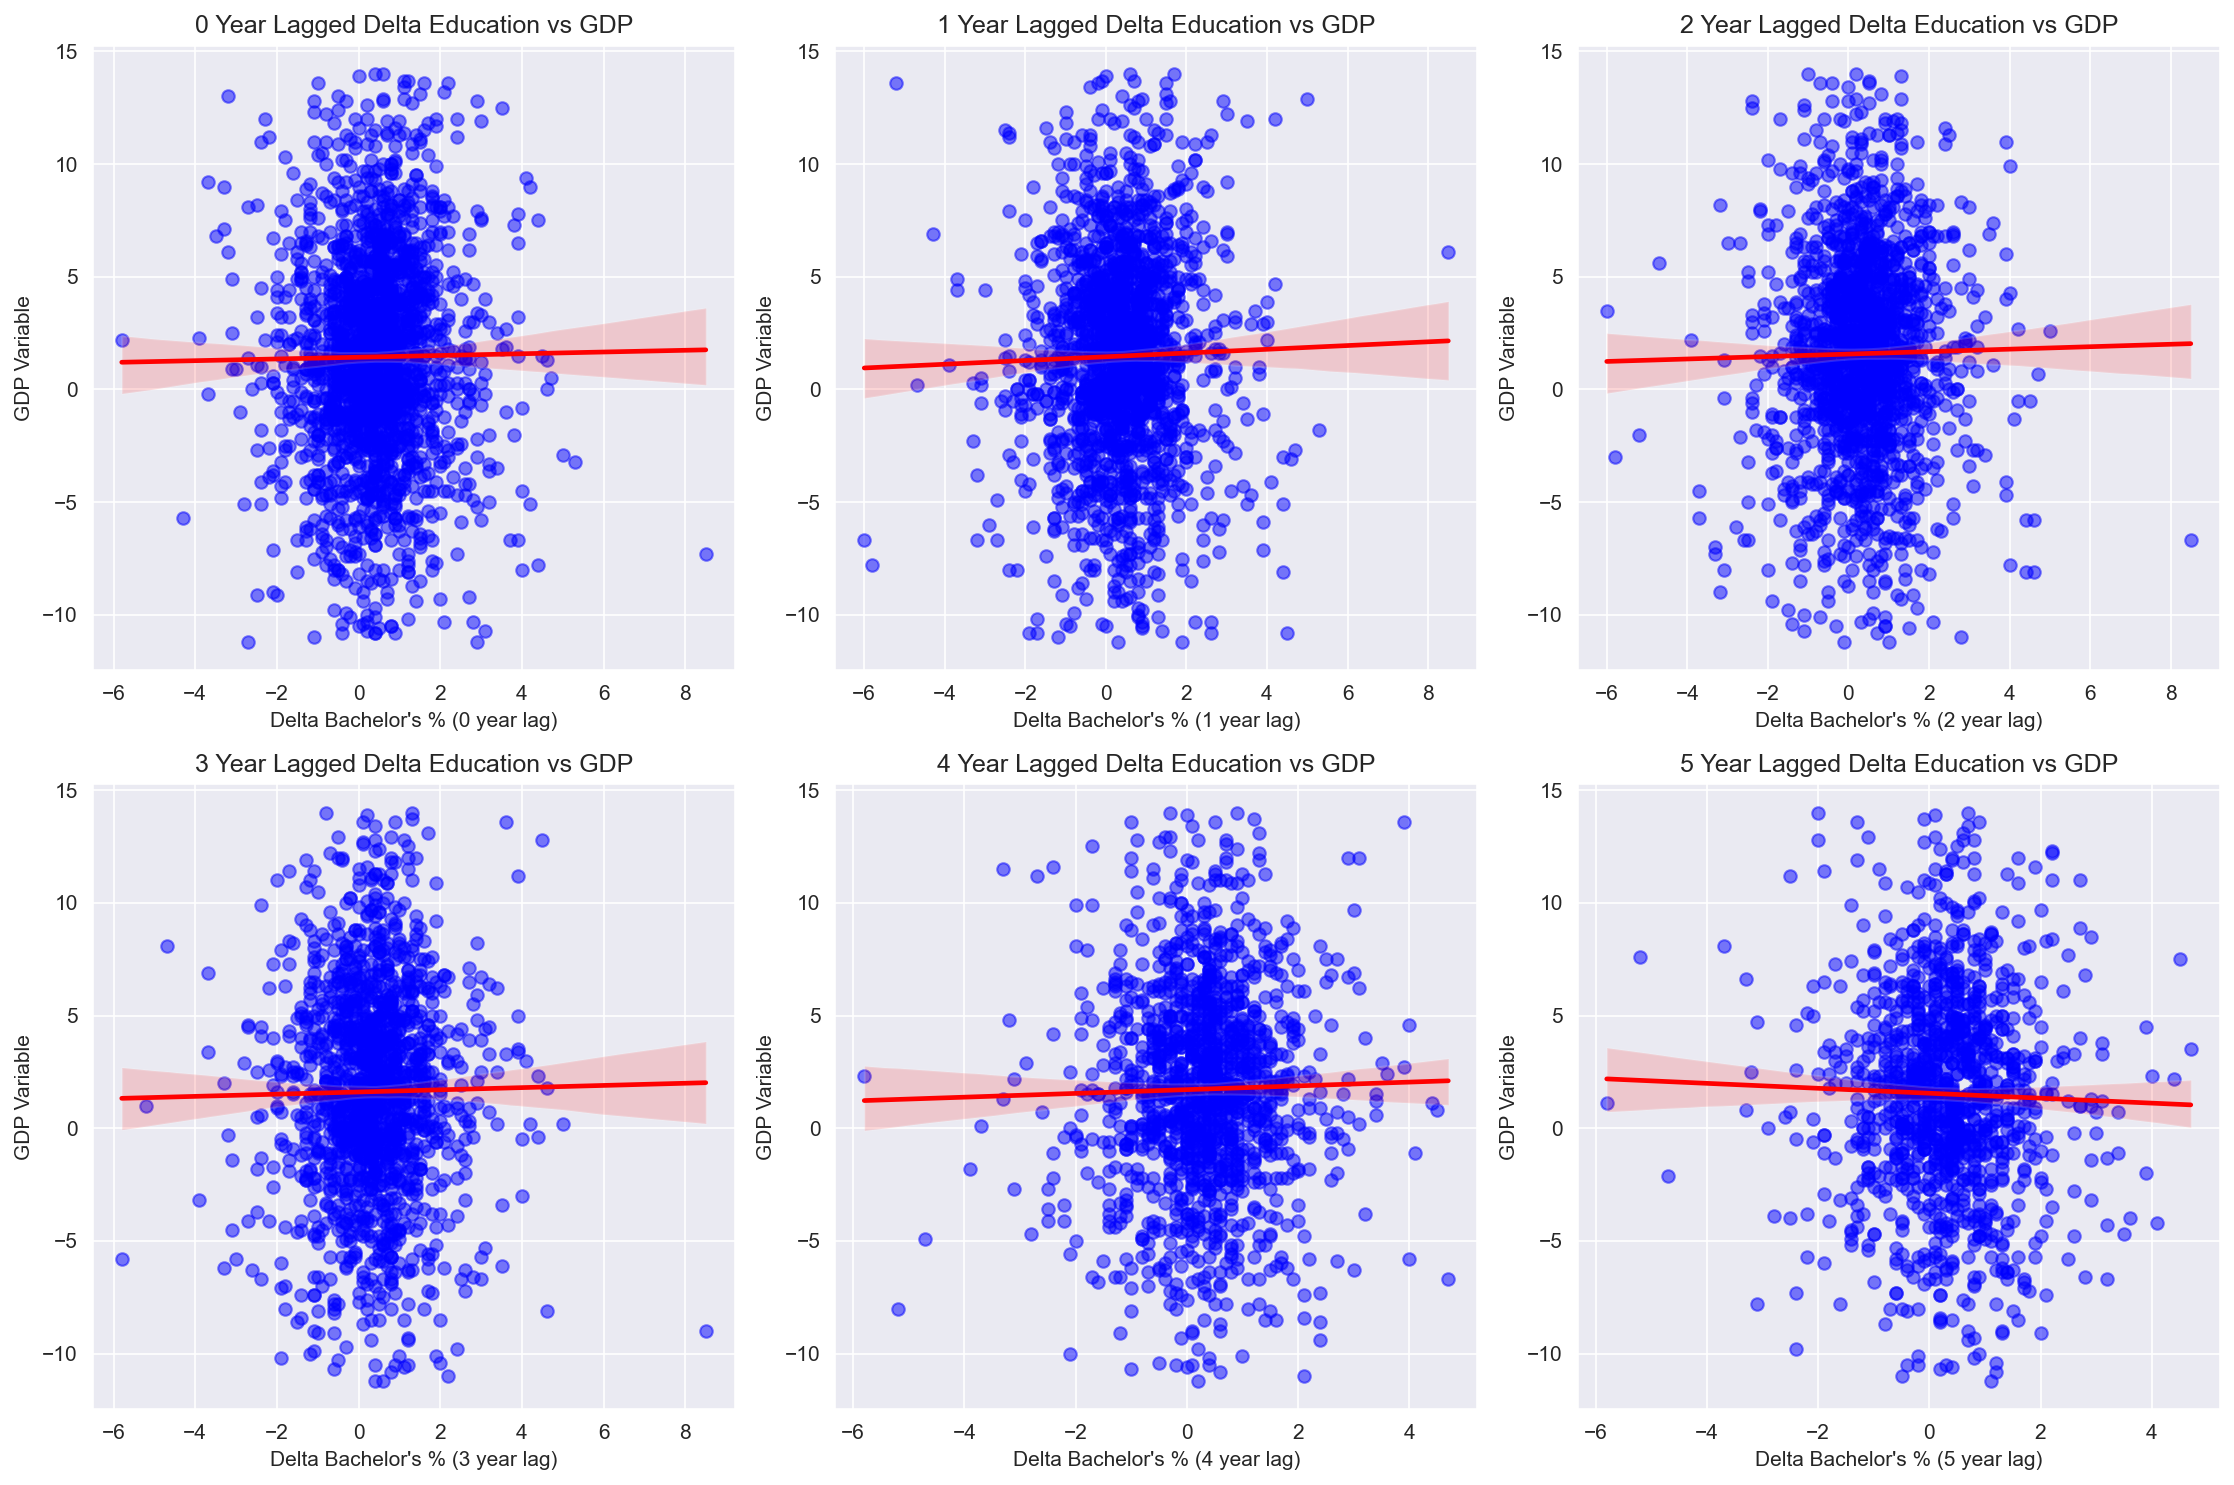

In [14]:
education_delta_df = create_lagged_delta_df(georgia_county_df, MAX_LAG, "County", PREDICTOR_COLUMN)

cleaned_delta_df = remove_outliers_iqr(education_delta_df, TARGET_COLUMN, 1.5)
display_lagged_delta_scatter_plots(cleaned_delta_df, MAX_LAG, TARGET_COLUMN)

#### The Results:

While the scatter plots showed significant dispersion, this line graph synthesizes those results to reveal the temporal behavior of our delta-on-delta predictor. Based on our analysis, we have the following insights:

* **Absence of a Temporal Peak:** Unlike the education levels, the Pearson correlation for education deltas shows no clear upward trend or "apex." The values fluctuate marginally between r = 0.009 and r = 0.021, eventually dipping to -0.026 at the 5-year lag. This suggests that annual changes in educational attainment do not have a cumulative linear "build-up" effect on GDP growth within this timeframe.
* **Persistent Statistical Insignificance:** The p-values for the delta-on-delta analysis are consistently high, ranging from 0.36 to 0.66. At no point does the lag reduce the p-value enough to approach the 0.05 significance threshold. This confirms that the year-over-year "flow" of new degrees is currently indistinguishable from statistical noise in predicting annual economic expansion.
* **Negligible Signal Strength:** With all r-values remaining below 0.03, the linear relationship is practically non-existent. This starkly contrasts with the "Level" analysis ($p < 10^{-16}$), reinforcing the conclusion that the total stock of human capital is an economically relevant predictor, while the annual rate of change is not.

#### Strategic Conclusion for Modeling:

The total lack of a significant signal in the Delta-on-Delta analysis indicates that raw annual changes in education should not be used as primary linear features. Instead, our modeling strategy will shift toward using **cumulative levels** or **smoothed rolling averages** to capture the impact of human capital. Since the delta fails to provide a leading indicator in a linear context, we will rely on Machine Learning models (such as Random Forest) to investigate if these deltas interact non-linearly with other variables to influence GDP.

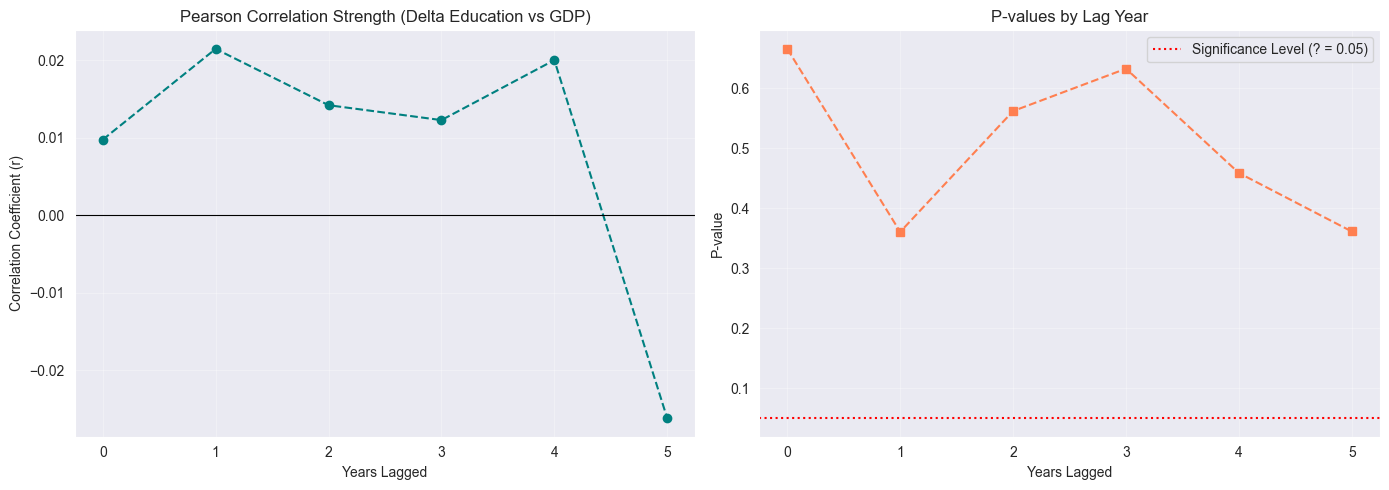

In [15]:
stats = calculate_delta_gdp_correlation(cleaned_delta_df, MAX_LAG, TARGET_COLUMN)
display_delta_lags_correlation(stats, MAX_LAG)

## Correlation and Statistical Significance: Delta-on-Delta Analysis

The correlation versus lag graph for the delta-on-delta analysis provides a striking visual confirmation of our earlier scatter plot observations. The left panel reveals an almost perfectly flat correlation trajectory, with values oscillating narrowly between r = 0.009 and r = 0.021 before dipping slightly negative at the 5-year lag (r = -0.026). This near-zero, directionless pattern stands in stark contrast to the education level analysis, where we observed a clear upward trend peaking at the 4-year lag.

The right panel tells an even more definitive story: the p-values remain stubbornly high across all lag periods, ranging from 0.36 to 0.66. Not a single lag period approaches the conventional significance threshold of ? = 0.05, indicated by the red dashed line. This persistent statistical insignificance confirms that the marginal fluctuations we observe in correlation values are well within the range of random noise.

**Key Takeaway:** While the education level metric showed both statistical significance (p < 10?16) and temporal structure (peaking at lag-4), the delta-on-delta approach fails on both counts. This fundamental divergence reinforces our strategic decision to model GDP growth as a function of **cumulative human capital stocks** rather than annual flows of new degree holders.

# EDA Conclusions and Strategic Implications

## Summary of Key Findings

Our exploratory data analysis across 159 Georgia counties (2010-2023) has revealed several critical insights about the relationship between educational attainment and economic growth:

### Finding 1: Education Level Shows Modest but Consistent Correlation
The **total stock of human capital** (Bachelor's degree attainment percentage) demonstrates a weak but statistically significant positive relationship with GDP growth. With correlation coefficients hovering around **r = 0.18-0.19** and p-values consistently below 10?16, we can confidently reject the null hypothesis that no relationship exists. However, the **low correlation magnitude** indicates that education alone explains only a small fraction of GDP variance.

### Finding 2: The 4-Year Lag Represents the Optimal "Reaction Time"
Among all temporal lags tested (0 through 5 years), the **4-year lag** produced the strongest linear signal (r = 0.1945, p < 10?16). This suggests that the economic returns to human capital investments may require approximately **four years to fully materialize** in measurable GDP growth. This "gestation period" likely reflects the time needed for:
- Recent graduates to enter the workforce
- Skilled workers to migrate to counties with better opportunities
- New businesses to capitalize on an educated labor pool
- Innovation and productivity gains to translate into economic output

### Finding 3: Annual Changes (Delta-on-Delta) Provide No Predictive Signal
In stark contrast to education levels, the **year-over-year change in educational attainment** shows virtually no correlation with GDP growth (r ~= 0.01-0.02, p > 0.35 across all lags). This fundamental divergence reveals that:
- The **existing stock** of educated workers matters far more than the **flow** of new graduates
- Counties with consistently high education levels grow more reliably than those experiencing rapid but short-term improvements
- Educational attainment operates as a **structural foundation** rather than a **dynamic trigger** for economic expansion

### Finding 4: High Variance Indicates a Multi-Factor System
The scatter plots reveal substantial dispersion even at the optimal 4-year lag. This high variance suggests that while education is a relevant predictor, GDP growth is influenced by a complex interplay of factors including:
- **Industry composition** (technology vs. agriculture vs. manufacturing)
- **Geographic advantages** (proximity to Atlanta, interstate access)
- **Infrastructure quality** (broadband, transportation)
- **State and national economic cycles** (recession, recovery, boom)
- **Local policy environment** (tax rates, business incentives)

## Implications for Modeling Strategy

These findings shape our approach to the subsequent modeling phase:

**1. Linear Models Will Likely Underperform**
With r2 values capped around 0.04 (r = 0.19)2 in simple correlation, basic linear regression cannot adequately capture the relationship. We must employ **non-linear algorithms** (Random Forest, Neural Networks) to detect higher-order interactions.

**2. Focus on Education Levels, Not Deltas**
Our feature engineering will prioritize **cumulative education stocks** and **lagged levels** rather than year-over-year changes. The 4-year lag will be emphasized as the primary predictor.

**3. Control Variables Are Essential**
To reduce unexplained variance, we'll include **population** and **year** as control variables, acknowledging that many counties may follow broader economic trends independent of education.

**4. The 2003-2009 "Data Desert" Must Be Addressed**
Before we can build predictive models across the full 2003-2023 period, we must resolve the missing education data gap. This leads directly to our next chapter.

# Imputation Experiment and Predictive Modeling

### Chapter Overview

Having established that educational attainment--particularly at a 4-year lag--demonstrates a statistically significant (though modest) relationship with GDP growth, we now confront a critical methodological challenge: **How do we handle the 2003-2009 "data desert" when building predictive models?**

This chapter addresses that question through a rigorous imputation experiment designed to answer two fundamental questions:

1. **Does the choice of imputation method significantly affect model performance?**
2. **Is education a valuable predictor at all, or can we achieve similar accuracy without it?**

### The Imputation Challenge

#### Why Imputation Matters for Lagged Features

Our EDA revealed that the **4-year lag** provides the strongest predictive signal. However, this creates a dependency problem:

```
To predict GDP in 2014, we need education data from 2010 [OK] (Available: ACS)
To predict GDP in 2013, we need education data from 2009 ? (Missing)
To predict GDP in 2012, we need education data from 2008 ? (Missing)
To predict GDP in 2011, we need education data from 2007 ? (Missing)
To predict GDP in 2010, we need education data from 2006 ? (Missing)
```

**The Question:** If we impute the 2003-2009 period, will different imputation assumptions propagate through the lag features and distort our model's performance on the 2010-2023 "gold standard" period?

#### Imputation Methods Under Investigation

We will create and benchmark **four distinct datasets**, all evaluated exclusively on the 2010-2023 period where complete education data exists:

**Dataset Descriptions:**

1. **Gold Standard**: Real data only -- No imputation (data unused) -- Evaluated on 2010-2023

2. **Linear Interpolation**: Steady growth assumption -- Linearly interpolate between 80% of 2010 value to 2010 -- Evaluated on 2010-2023

3. **Backfill**: Stationary assumption -- Carry 2010 value backward -- Evaluated on 2010-2023

4. **Baseline**: No education features -- N/A (education excluded) -- Evaluated on 2010-2023

**Critical Design Decision:** All four datasets are evaluated on the **same 2010-2023 window**. This ensures an apples-to-apples comparison and isolates the effect of imputation method on lag features during the evaluation period.

### Experimental Design

#### Evaluation Framework

For each of the four datasets, we will train and evaluate three model architectures:

**1. Linear Regression**
- Establishes the baseline linear performance ceiling
- Fast, interpretable, but limited to linear relationships
- Expected R2: 0.03-0.08 (based on EDA correlation findings)

**2. Random Forest (100 trees, max depth 10)**
- Captures non-linear interactions and threshold effects
- Provides feature importance rankings to validate EDA insights
- Robust to outliers and multicollinearity
- Expected R2: 0.10-0.20 (if non-linear patterns exist)

**3. Neural Network (MLP: 64->32 hidden units)**
- Detects complex, high-dimensional patterns
- Early stopping to prevent overfitting
- May struggle with limited sample size (~1,400 county-year observations after cleaning)
- Expected R2: 0.05-0.15

#### Feature Engineering

Based on our EDA findings, each model (except Baseline) will use the following features:

**Primary Predictors:**
- `education_t` (current year education level)
- `education_lag1` (1-year lag)
- `education_lag2` (2-year lag)
- `education_lag4` ? **(4-year lag -- strongest signal from EDA)**

**Control Variables:**
- `TOT_POP` (total population, to control for county size)
- `Year` (to capture temporal trends and economic cycles)

**Target Variable:**
- `Percent_Change_Real_GDP` (annual GDP growth rate)

#### Data Cleaning

To ensure robust model training, we apply the same **IQR outlier removal** used in the EDA phase:
- Calculate Q1 (25th percentile) and Q3 (75th percentile) of GDP growth
- Remove observations outside [Q1 - 1.5xIQR, Q3 + 1.5xIQR]
- Typically removes ~5-10% of extreme GDP volatility cases

#### Train-Test Split

Each dataset undergoes an **80/20 train-test split** with `random_state=42` to ensure reproducibility. Model performance is reported on the held-out test set to prevent overfitting.

### Success Criteria and Interpretation Thresholds

#### Imputation Method Evaluation

**Hypothesis:** If imputation method doesn't matter, all three education-based datasets should perform similarly.

**Decision Rules:**
- If |R2_Gold - R2_Linear| < 0.02 **AND** |R2_Gold - R2_Backfill| < 0.02
  -> **Imputation method is irrelevant**; safe to use either approach for 2003-2009

- If differences exceed 0.02
  -> **Imputation choice affects results**; prefer Gold Standard approach (use only 2010+ data)

#### Education Feature Value Assessment

**Hypothesis:** If education provides meaningful predictive power, education-based models should outperform Baseline.

**Decision Rules:**
- If R2_Education > R2_Baseline + 0.05
  -> **Education is a valuable predictor**; worth including in final model

- If 0 < (R2_Education - R2_Baseline) < 0.05
  -> **Education provides modest improvement**; include but recognize other factors dominate

- If R2_Education <= R2_Baseline
  -> **Education does not improve predictions**; GDP growth driven by other factors

#### Model Complexity Justification

**Hypothesis:** If non-linear models significantly outperform Linear Regression, complex interactions exist.

**Decision Rules:**
- If R2_RandomForest > R2_LinearRegression + 0.05
  -> **Non-linear patterns exist**; use Random Forest for final model

- If difference < 0.05
  -> **Relationship is predominantly linear**; simpler models preferred for interpretability

### Expected Outcomes and Next Steps

Based on our EDA findings (r ~= 0.18), we anticipate:
- **Weak overall predictive power** (R2 < 0.20 across all models)
- **Random Forest outperforming Linear Regression** (if non-linearity exists)
- **Education models marginally better than Baseline** (education signal is real but weak)
- **Similar performance across Gold/Linear/Backfill** (imputation method likely doesn't matter much)

If these expectations hold, our next steps would be to:
1. Incorporate additional features (industry composition, infrastructure metrics)
2. Test spatial lag models (neighboring county spillovers)
3. Consider ensemble approaches combining multiple models

The results of this imputation experiment will be presented in the next section, where we analyze model performance across all twelve combinations (4 datasets x 3 models) and draw final conclusions about the viability of education as a GDP predictor.

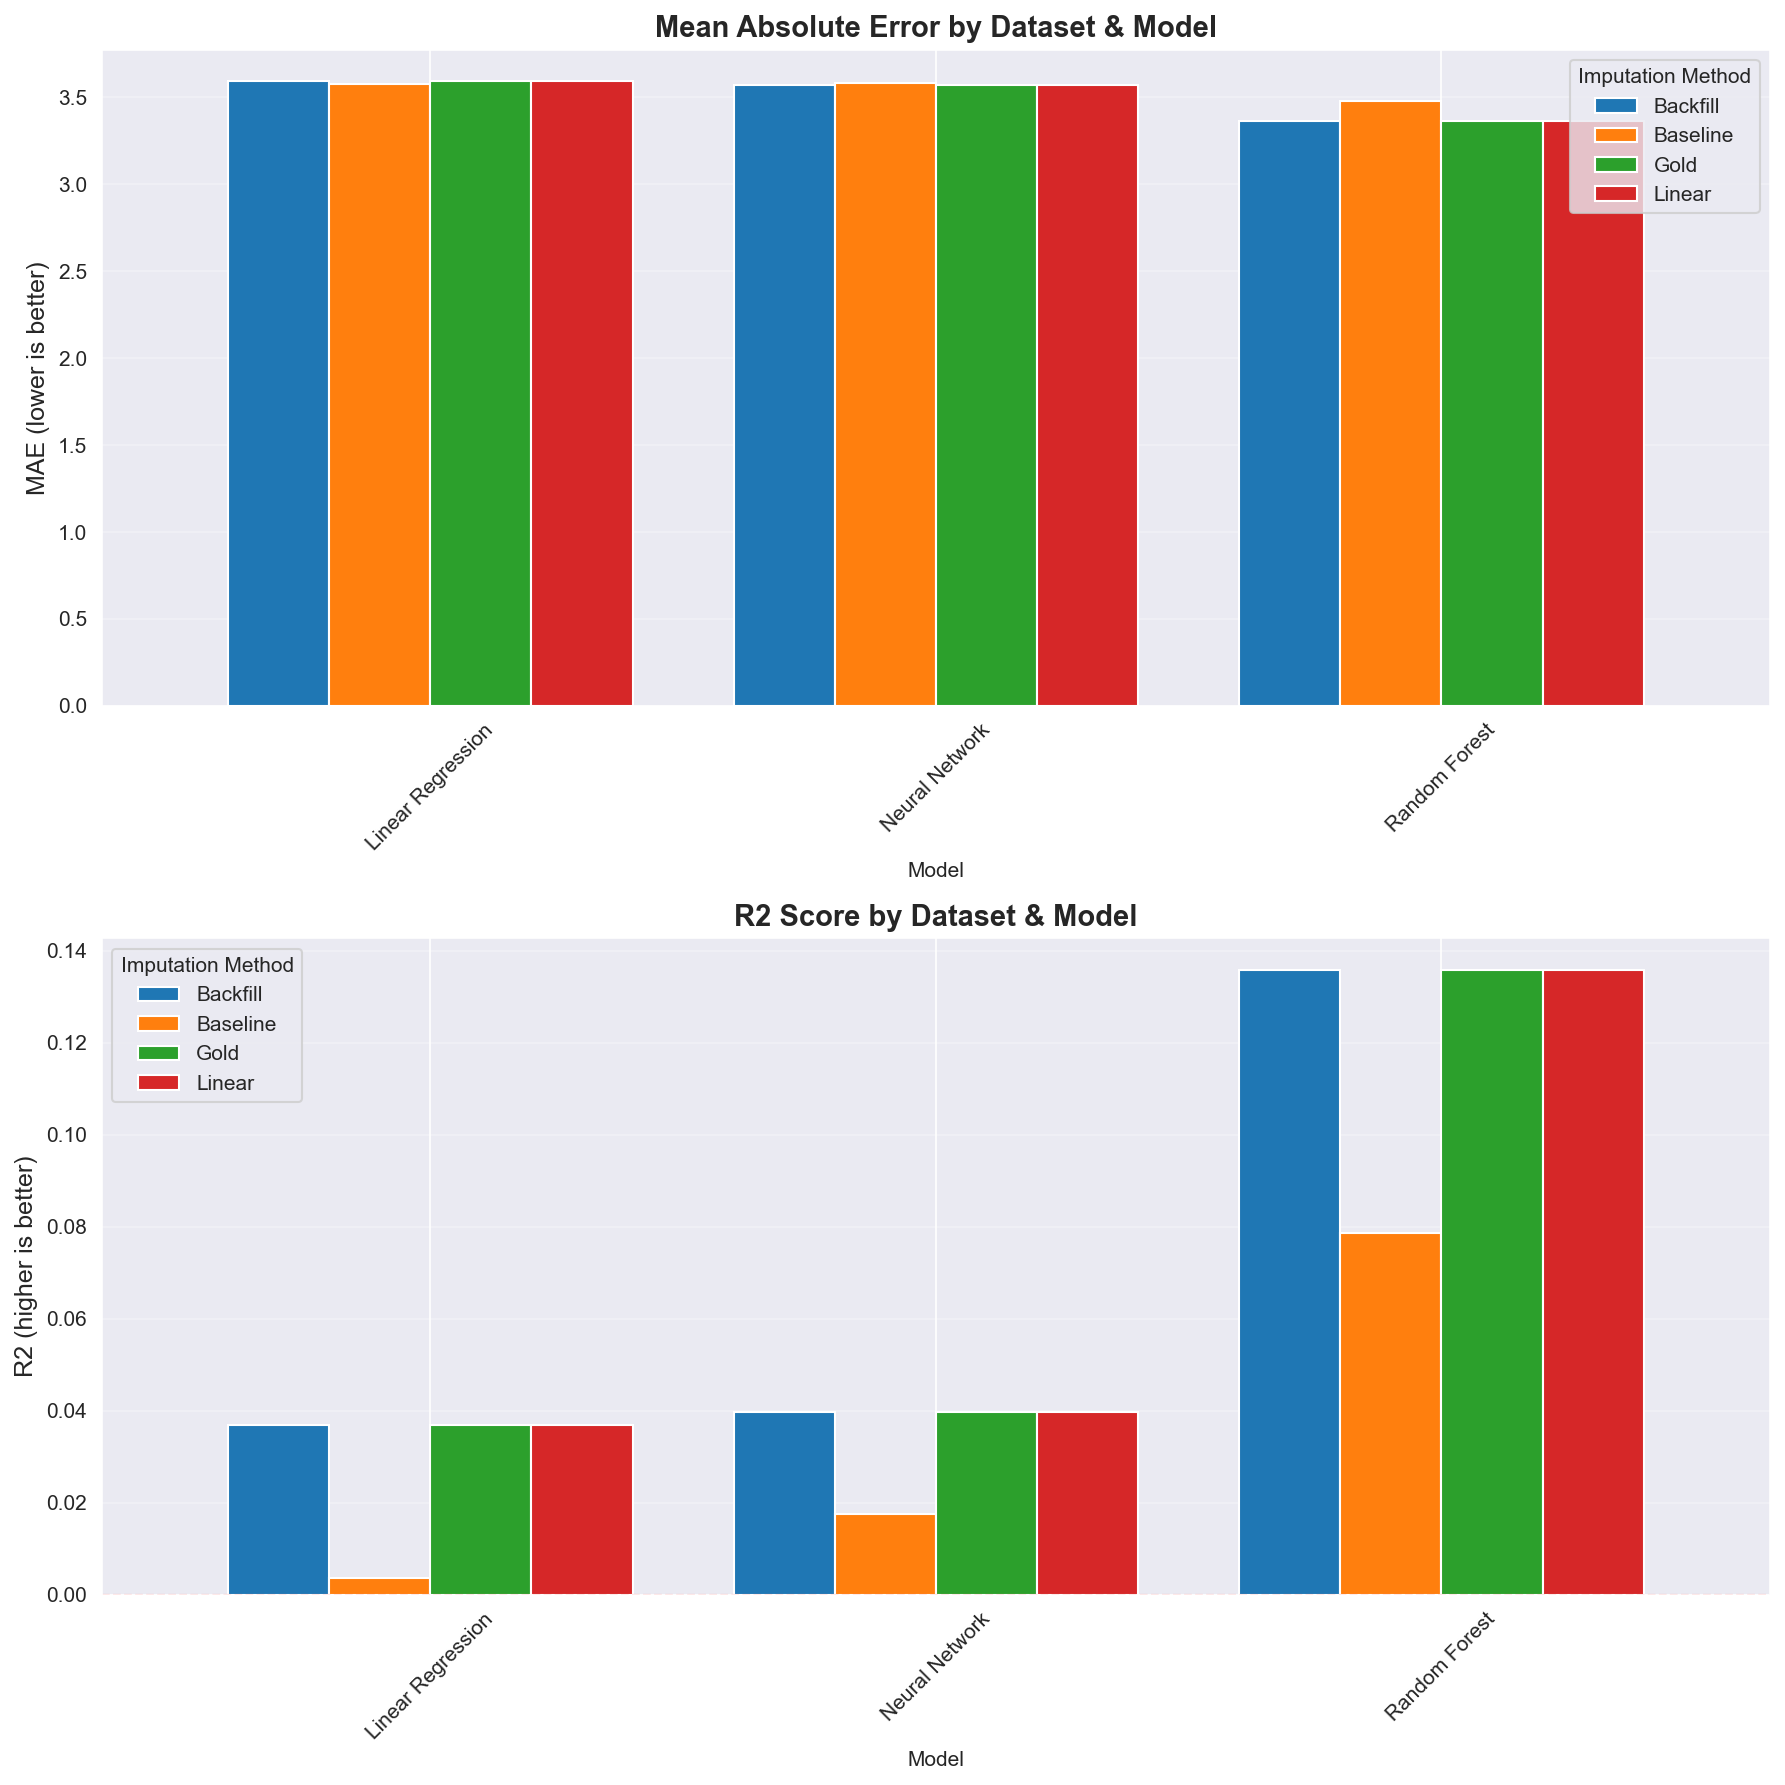

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

georgia_county_full_df = pd.read_csv(georgia_county_dataset_path)
RELEVANT_COLUMNS_FULL = ["County", "Year", TARGET_COLUMN, PREDICTOR_COLUMN, POPULATION_COLUMN]
full_df = georgia_county_full_df[RELEVANT_COLUMNS_FULL].sort_values(by=ID_COLUMNS)

def create_imputation_datasets(df, predictor_col):
    datasets = {}

    df_gold = df[df['Year'] >= 2010].copy()
    datasets['Gold'] = df_gold

    df_linear = df.copy()
    for county in df_linear['County'].unique():
        county_mask = df_linear['County'] == county
        val_2010_series = df_linear.loc[county_mask & (df_linear['Year'] == 2010), predictor_col]

        if len(val_2010_series) > 0 and not pd.isna(val_2010_series.iloc[0]):
            val_2010 = val_2010_series.iloc[0]
            val_2000 = val_2010 * 0.8

            for year in range(2003, 2010):
                progress = (year - 2000) / (2010 - 2000)
                interpolated_val = val_2000 + (val_2010 - val_2000) * progress
                year_mask = df_linear['Year'] == year
                df_linear.loc[county_mask & year_mask, predictor_col] = interpolated_val

    df_linear = df_linear[df_linear['Year'] >= 2010].copy()
    datasets['Linear'] = df_linear

    df_backfill = df.copy()
    for county in df_backfill['County'].unique():
        county_mask = df_backfill['County'] == county
        val_2010_series = df_backfill.loc[county_mask & (df_backfill['Year'] == 2010), predictor_col]

        if len(val_2010_series) > 0 and not pd.isna(val_2010_series.iloc[0]):
            val_2010 = val_2010_series.iloc[0]
            for year in range(2003, 2010):
                year_mask = df_backfill['Year'] == year
                df_backfill.loc[county_mask & year_mask, predictor_col] = val_2010

    df_backfill = df_backfill[df_backfill['Year'] >= 2010].copy()
    datasets['Backfill'] = df_backfill

    df_baseline = df[df['Year'] >= 2010].copy()
    datasets['Baseline'] = df_baseline

    return datasets

def remove_outliers_iqr(df: pd.DataFrame, column: str, multiplier: float = 1.5) -> pd.DataFrame:
    q_1 = df[column].quantile(0.25)
    q_3 = df[column].quantile(0.75)
    iqr = q_3 - q_1
    lower_bound = q_1 - multiplier * iqr
    upper_bound = q_3 + multiplier * iqr
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

def prepare_model_features(df, include_education=True, optimal_lag=4):
    df_feat = df.copy()
    df_feat = remove_outliers_iqr(df_feat, TARGET_COLUMN)

    if include_education:
        df_feat['education_lag4'] = df_feat.groupby('County')[PREDICTOR_COLUMN].shift(optimal_lag)
        df_feat['education_t'] = df_feat[PREDICTOR_COLUMN]
        df_feat['education_lag1'] = df_feat.groupby('County')[PREDICTOR_COLUMN].shift(1)
        df_feat['education_lag2'] = df_feat.groupby('County')[PREDICTOR_COLUMN].shift(2)

    df_feat = df_feat.dropna(subset=[TARGET_COLUMN])

    feature_cols = []
    if include_education:
        feature_cols = ['education_t', 'education_lag1', 'education_lag2', 'education_lag4']
    feature_cols.extend([POPULATION_COLUMN, 'Year'])

    df_feat = df_feat.dropna(subset=feature_cols)

    X = df_feat[feature_cols]
    y = df_feat[TARGET_COLUMN]

    return X, y

def train_evaluate_models(X_train, X_test, y_train, y_test, dataset_name):
    results = {}

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    lr = LinearRegression()
    lr.fit(X_train, y_train)
    lr_pred = lr.predict(X_test)
    results['Linear Regression'] = {
        'MAE': mean_absolute_error(y_test, lr_pred),
        'R2': r2_score(y_test, lr_pred)
    }

    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    results['Random Forest'] = {
        'MAE': mean_absolute_error(y_test, rf_pred),
        'R2': r2_score(y_test, rf_pred),
        'feature_importance': dict(zip(X_train.columns, rf.feature_importances_))
    }

    nn = MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        max_iter=500,
        random_state=42,
        early_stopping=True
    )
    nn.fit(X_train_scaled, y_train)
    nn_pred = nn.predict(X_test_scaled)
    results['Neural Network'] = {
        'MAE': mean_absolute_error(y_test, nn_pred),
        'R2': r2_score(y_test, nn_pred)
    }

    return results

datasets = create_imputation_datasets(full_df, PREDICTOR_COLUMN)
all_results = {}

for dataset_name, df in datasets.items():
    include_edu = (dataset_name != 'Baseline')
    X, y = prepare_model_features(df, include_education=include_edu)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    results = train_evaluate_models(X_train, X_test, y_train, y_test, dataset_name)
    all_results[dataset_name] = results

plot_data = []
for dataset, models in all_results.items():
    for model, metrics in models.items():
        plot_data.append({
            'Dataset': dataset,
            'Model': model,
            'MAE': metrics['MAE'],
            'R2': metrics['R2']
        })

results_df = pd.DataFrame(plot_data)

fig, axes = plt.subplots(2, 1, figsize=(12, 12), dpi=150)

mae_pivot = results_df.pivot(index='Model', columns='Dataset', values='MAE')
mae_pivot.plot(kind='bar', ax=axes[0], rot=45, width=0.8)
axes[0].set_title('Mean Absolute Error by Dataset & Model', fontsize=14, fontweight='bold')
axes[0].set_ylabel('MAE (lower is better)', fontsize=12)
axes[0].legend(title='Imputation Method', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

r2_pivot = results_df.pivot(index='Model', columns='Dataset', values='R2')
r2_pivot.plot(kind='bar', ax=axes[1], rot=45, width=0.8)
axes[1].set_title('R2 Score by Dataset & Model', fontsize=14, fontweight='bold')
axes[1].set_ylabel('R2 (higher is better)', fontsize=12)
axes[1].legend(title='Imputation Method', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()